In [1]:
import torch
import torchvision
from torchvision.transforms import v2


print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

Torch version: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
CUDA device count: 1


In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

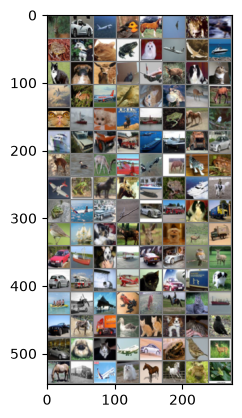

deer  car   plane bird  horse plane frog  deer  frog  horse cat   frog  dog   plane bird  ship  cat   dog   deer  cat   plane deer  dog   cat   plane deer  plane bird  cat   frog  deer  deer  cat   ship  dog   deer  ship  frog  horse bird  ship  car   truck truck ship  plane truck car   deer  bird  deer  plane plane horse cat   frog  plane frog  horse horse ship  frog  ship  horse frog  plane car   bird  car   truck dog   truck bird  ship  cat   deer  deer  dog   deer  truck car   ship  dog   truck car   car   bird  deer  car   truck cat   plane cat   car   truck dog   ship  plane plane frog  horse horse cat   ship  car   deer  truck bird  cat   dog   cat   bird  car   dog   cat   plane car   frog  bird  deer  horse truck plane dog   horse horse frog  frog 


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [4]:
import torch.nn as nn
import torch.nn.functional as F
device = torch.device(
    "cpu"
)

class Net(nn.Module):

    
    class ResBlock(nn.Module):
        
        def __init__(self,InputDepth: int,OutputDepth: int, FilterSize: int, stride = 1) -> None:
            super().__init__()
            self.InputDepth = InputDepth
            self.OutputDepth = OutputDepth
            self.stride = stride

            self.conv1 = nn.Conv2d(InputDepth,OutputDepth,FilterSize,stride, padding= 1, bias=False)
            self.conv2 = nn.Conv2d(OutputDepth,OutputDepth,FilterSize, padding= 1, bias=False)
            
            self.bn1 = nn.BatchNorm2d(self.OutputDepth)
            self.bn2 = nn.BatchNorm2d(self.OutputDepth)

            self.ShortcutConv = None
            if stride != 1 or InputDepth != OutputDepth:
                self.ShortcutConv = nn.Sequential(
                    nn.Conv2d(InputDepth,OutputDepth,1,stride, bias=False),
                    nn.BatchNorm2d(OutputDepth)
                )

        def forward(self,x):
            i = x
            x = self.conv1(x)
            x = self.bn1(x)
            x = F.relu(x)

            x = self.conv2(x)
            x = self.bn2(x)

            if self.ShortcutConv is not None:
                i = self.ShortcutConv(i)
            x += i
            x = F.relu(x)
            return x

    def __init__(self):
        super().__init__()
        # 3 => 32 => 32 => 32 => 64 => 64 => 128 => 128 => 256 => 256 (8 layers)
        self.layers = nn.Sequential(
            self.ResBlock(3,32,3),
            self.ResBlock(32,32,3),
            self.ResBlock(32,32,3),
            self.ResBlock(32,64,3,2),
            self.ResBlock(64,64,3),
            self.ResBlock(64,128,3,2),
            self.ResBlock(128,128,3),
            self.ResBlock(128,256,3,2),
            self.ResBlock(256,256,3)
        )
        self.fc1 = nn.Linear(256 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 10)

        self.dropout = nn.Dropout(p=0.5)

    # Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => 
    def forward(self, x):
        # 3 x 32 x 32 (Initial)
        x = self.layers(x)
        # 256 x 4 x 4 (Block 3)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


net = Net().to(device)
sum(p.numel() for p in net.parameters() if p.requires_grad)

3297330

In [13]:
import torch.optim as optim
from timm.scheduler import CosineLRScheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=3e-4, weight_decay=5e-4, betas=(0.9,0.99))
scheduler = CosineLRScheduler(
    optimizer,
    t_initial= 15 * len(trainloader),
    lr_min=1e-6,
    warmup_t=3 * len(trainloader),   # 5 warmup epochs
    warmup_lr_init=1e-7,
)

In [14]:
for epoch in range(15):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        scheduler.step(epoch * len(trainloader) + i)
        # print statistics
        running_loss += loss.item()
        if i % 50 == 49:  # print every 50 mini-batches
            print(f"Epoch {epoch+1:2d} | Batch {i+1:5d}/{len(trainloader)} | Avg loss: {running_loss/50:.4f} | LR {optimizer.param_groups[0]['lr']:.6f} ")
            running_loss = 0.0

print('Finished Training')

Epoch  1 | Batch    50/391 | Avg loss: 2.3557 | LR 0.000013 
Epoch  1 | Batch   100/391 | Avg loss: 2.2588 | LR 0.000025 
Epoch  1 | Batch   150/391 | Avg loss: 2.1212 | LR 0.000038 
Epoch  1 | Batch   200/391 | Avg loss: 1.9297 | LR 0.000051 
Epoch  1 | Batch   250/391 | Avg loss: 1.8150 | LR 0.000064 
Epoch  1 | Batch   300/391 | Avg loss: 1.7166 | LR 0.000077 
Epoch  1 | Batch   350/391 | Avg loss: 1.6242 | LR 0.000089 
Epoch  2 | Batch    50/391 | Avg loss: 1.4708 | LR 0.000113 
Epoch  2 | Batch   100/391 | Avg loss: 1.4549 | LR 0.000125 
Epoch  2 | Batch   150/391 | Avg loss: 1.3966 | LR 0.000138 
Epoch  2 | Batch   200/391 | Avg loss: 1.3676 | LR 0.000151 
Epoch  2 | Batch   250/391 | Avg loss: 1.3229 | LR 0.000164 
Epoch  2 | Batch   300/391 | Avg loss: 1.3098 | LR 0.000177 
Epoch  2 | Batch   350/391 | Avg loss: 1.2695 | LR 0.000189 
Epoch  3 | Batch    50/391 | Avg loss: 1.1488 | LR 0.000213 
Epoch  3 | Batch   100/391 | Avg loss: 1.1053 | LR 0.000225 
Epoch  3 | Batch   150/3

In [17]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    net.eval()
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 81 %


In [16]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    net.eval()
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 84.4 %
Accuracy for class: car   is 91.2 %
Accuracy for class: bird  is 72.8 %
Accuracy for class: cat   is 70.2 %
Accuracy for class: deer  is 79.4 %
Accuracy for class: dog   is 72.6 %
Accuracy for class: frog  is 84.1 %
Accuracy for class: horse is 84.2 %
Accuracy for class: ship  is 89.8 %
Accuracy for class: truck is 88.9 %
